In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from torch import nn, optim

In [2]:
dx = 0.01; dt = 0.01; Length = 5; Time = 1

In [3]:
class My_PINNS(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = torch.nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 30),
            nn.Tanh(),
            nn.Linear(30, 20),
            nn.Tanh(),
            nn.Linear(20, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        )
    def forward(self, x):
        out = self.network(x)
        return out

In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
My_model = My_PINNS().to(device)

In [5]:
criterion = nn.MSELoss().to(device)

optimizer_ADAM = optim.Adam(My_model.parameters())

optimizer_LBFGS = optim.LBFGS(
    My_model.parameters(),
    lr=1.0,                   # keep 1.0 for full Newton steps
    max_iter=50,              # per-call iterations; 20–100 is typical
    max_eval=None,            # let PyTorch infer from max_iter (usually ~1.25*max_iter)
    history_size=50,          # default; memory of past updates
    tolerance_grad=1e-9,      # stricter than default for PDE accuracy
    tolerance_change=1e-9,    # stricter to push convergence
    line_search_fn="strong_wolfe"
)

In [6]:
def to_coords(a, b):
    return torch.stack(torch.meshgrid(a, b, indexing='ij')).reshape(2, -1).T

In [7]:
def X_and_T(dx = 0.1, dt = 0.1, Length = 2, Time = 1, device=device):
    
    x = torch.arange(-Length/2, Length/2 + dx, dx, device=device)
    t = torch.arange(0, Time + dt, dt, device=device)
    
    return to_coords(x, t)

In [8]:
X_and_T_Values = X_and_T()

In [9]:
print(X_and_T_Values)

tensor([[-1.0000,  0.0000],
        [-1.0000,  0.1000],
        [-1.0000,  0.2000],
        [-1.0000,  0.3000],
        [-1.0000,  0.4000],
        [-1.0000,  0.5000],
        [-1.0000,  0.6000],
        [-1.0000,  0.7000],
        [-1.0000,  0.8000],
        [-1.0000,  0.9000],
        [-1.0000,  1.0000],
        [-0.9000,  0.0000],
        [-0.9000,  0.1000],
        [-0.9000,  0.2000],
        [-0.9000,  0.3000],
        [-0.9000,  0.4000],
        [-0.9000,  0.5000],
        [-0.9000,  0.6000],
        [-0.9000,  0.7000],
        [-0.9000,  0.8000],
        [-0.9000,  0.9000],
        [-0.9000,  1.0000],
        [-0.8000,  0.0000],
        [-0.8000,  0.1000],
        [-0.8000,  0.2000],
        [-0.8000,  0.3000],
        [-0.8000,  0.4000],
        [-0.8000,  0.5000],
        [-0.8000,  0.6000],
        [-0.8000,  0.7000],
        [-0.8000,  0.8000],
        [-0.8000,  0.9000],
        [-0.8000,  1.0000],
        [-0.7000,  0.0000],
        [-0.7000,  0.1000],
        [-0.7000,  0

In [10]:
def BCs_and_ICs(dx = 0.1, dt = 0.1, Length = 2, Time = 1, device=device):
    
    x = torch.arange(-Length/2, Length/2 + dx, dx, device=device)
    t = torch.arange(0, Time + dt, dt, device=device)
    
    BC1 = to_coords(x[0:1], t)
    BC2 = to_coords(x[-1:], t)
    IC = to_coords(x, t[0:1])
    
    return torch.cat([BC1, BC2, IC])

In [11]:
BCs_and_ICs_Coor = BCs_and_ICs()

In [12]:
print(BCs_and_ICs_Coor)

tensor([[-1.0000,  0.0000],
        [-1.0000,  0.1000],
        [-1.0000,  0.2000],
        [-1.0000,  0.3000],
        [-1.0000,  0.4000],
        [-1.0000,  0.5000],
        [-1.0000,  0.6000],
        [-1.0000,  0.7000],
        [-1.0000,  0.8000],
        [-1.0000,  0.9000],
        [-1.0000,  1.0000],
        [ 1.0000,  0.0000],
        [ 1.0000,  0.1000],
        [ 1.0000,  0.2000],
        [ 1.0000,  0.3000],
        [ 1.0000,  0.4000],
        [ 1.0000,  0.5000],
        [ 1.0000,  0.6000],
        [ 1.0000,  0.7000],
        [ 1.0000,  0.8000],
        [ 1.0000,  0.9000],
        [ 1.0000,  1.0000],
        [-1.0000,  0.0000],
        [-0.9000,  0.0000],
        [-0.8000,  0.0000],
        [-0.7000,  0.0000],
        [-0.6000,  0.0000],
        [-0.5000,  0.0000],
        [-0.4000,  0.0000],
        [-0.3000,  0.0000],
        [-0.2000,  0.0000],
        [-0.1000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.1000,  0.0000],
        [ 0.2000,  0.0000],
        [ 0.3000,  0

In [13]:
def BCs_and_ICs(dx = 0.1, dt = 0.1, Length = 2, Time = 1, device=device):
    
    x = torch.arange(-Length/2, Length/2 + dx, dx, device=device)
    t = torch.arange(0, Time + dt, dt, device=device)
    
    BC1 = to_coords(x[0:1], t)
    BC2 = to_coords(x[-1:], t)
    IC = to_coords(x, t[0:1])

    y_BC1 = torch.zeros(len(BC1), device=device)
    y_BC2 = torch.zeros(len(BC2), device=device)
    y_IC = -torch.sin(torch.pi * IC[:, 0])

    return torch.cat([y_BC1, y_BC2, y_IC]).unsqueeze(1)

In [14]:
BCs_and_ICs_Values = BCs_and_ICs()

In [15]:
def PDEs(X_and_T_Values, u):
    du_dX_and_T_Values = torch.autograd.grad(
        u,
        X_and_T_Values,
        grad_outputs = torch.ones_like(u),
        create_graph = True,
        retain_graph = True
    )[0]
    
    du_dx = du_dX_and_T_Values[:, 0]
    du_dt = du_dX_and_T_Values[:, 1]

    d2u_dX_and_T_Values2 = torch.autograd.grad(
        du_dx,
        X_and_T_Values,
        grad_outputs = torch.ones_like(du_dx),
        create_graph = True,
        retain_graph = True
    )[0]


    d2u_dx2 = d2u_dX_and_T_Values2[:, 0]

    return du_dt, du_dx, d2u_dx2

In [16]:
def train_model(nu = 0.01/torch.pi, X_and_T_Values=X_and_T_Values, BCs_and_ICs_Coor=BCs_and_ICs_Coor, BCs_and_ICs_Values=BCs_and_ICs_Values, epochs = 10000, device=device):
    step = 0
    train_losses = []

    My_model.train()
    
    X_and_T_Values = X_and_T_Values.to(device).requires_grad_(True)
    BCs_and_ICs_Coor = BCs_and_ICs_Coor.to(device)
    BCs_and_ICs_Values = BCs_and_ICs_Values.to(device)
    
    # -------- ADAM pretraining --------
    for e in range(epochs):
        running_loss = 0
        optimizer_ADAM.zero_grad()
        
        # NN - ICs and BCs
        y_pred = My_model(BCs_and_ICs_Coor)
        loss_IC_BC = criterion(y_pred, BCs_and_ICs_Values)
        
        #PDE
        u = My_model(X_and_T_Values)
        du_dt, du_dx, d2u_dx2 = PDEs(X_and_T_Values, u)
        EQ = du_dt + u.squeeze()*du_dx - nu * d2u_dx2
        loss_PDE = criterion(EQ,  torch.zeros_like(EQ))

        total_loss = loss_IC_BC + loss_PDE
        total_loss.backward()
        optimizer_ADAM.step()

        if e % 50 == 0:
            print(f"[ADAM] epoch {e:5d}  total={total_loss.item():.6e}  "
                  f"BC/IC={loss_IC_BC.item():.6e}  PDE={loss_PDE.item():.6e}")
    # -------- LBFGS refinement --------
    def closure():
        optimizer_LBFGS.zero_grad()
        
        # NN - ICs and BCs
        y_pred = My_model(BCs_and_ICs_Coor)
        loss_IC_BC = criterion(y_pred, BCs_and_ICs_Values)
            
        #PDE
        u = My_model(X_and_T_Values)
        du_dt, du_dx, d2u_dx2 = PDEs(X_and_T_Values, u)
        EQ = du_dt + u.squeeze()*du_dx - nu * d2u_dx2
        loss_PDE = criterion(EQ,  torch.zeros_like(EQ))
    
        total_loss = loss_IC_BC + loss_PDE
        total_loss.backward()
        return total_loss
    final_loss = optimizer_LBFGS.step(closure)
    print(f"[LBFGS] final loss = {final_loss.item():.6e}")

In [17]:
train_model()

[ADAM] epoch     0  total=2.423179e-01  BC/IC=2.422808e-01  PDE=3.706937e-05
[ADAM] epoch    50  total=1.944515e-01  BC/IC=1.918725e-01  PDE=2.578987e-03
[ADAM] epoch   100  total=1.802523e-01  BC/IC=1.770365e-01  PDE=3.215768e-03
[ADAM] epoch   150  total=1.193679e-01  BC/IC=1.017840e-01  PDE=1.758391e-02
[ADAM] epoch   200  total=8.881018e-02  BC/IC=6.371617e-02  PDE=2.509402e-02
[ADAM] epoch   250  total=7.675548e-02  BC/IC=5.497234e-02  PDE=2.178314e-02
[ADAM] epoch   300  total=6.722252e-02  BC/IC=4.795235e-02  PDE=1.927016e-02
[ADAM] epoch   350  total=5.698746e-02  BC/IC=3.917492e-02  PDE=1.781254e-02
[ADAM] epoch   400  total=4.320168e-02  BC/IC=2.982923e-02  PDE=1.337244e-02
[ADAM] epoch   450  total=3.181319e-02  BC/IC=2.152615e-02  PDE=1.028704e-02
[ADAM] epoch   500  total=2.549094e-02  BC/IC=1.529592e-02  PDE=1.019502e-02
[ADAM] epoch   550  total=2.105963e-02  BC/IC=1.109128e-02  PDE=9.968352e-03
[ADAM] epoch   600  total=1.516933e-02  BC/IC=8.722857e-03  PDE=6.446471e-03

In [18]:
# Testing our model
X_and_T_Values = X_and_T(dx = 0.01, dt = 0.01, Length = 5, Time = 1, device=device)
print(X_and_T_Values)
print(X_and_T_Values.shape)

tensor([[-2.5000,  0.0000],
        [-2.5000,  0.0100],
        [-2.5000,  0.0200],
        ...,
        [ 2.5000,  0.9800],
        [ 2.5000,  0.9900],
        [ 2.5000,  1.0000]])
torch.Size([50601, 2])


In [23]:
My_model.eval()
dx = 0.001; dt = 0.001; Length = 5; Time = 2

X_and_T_Values = X_and_T(dx=dx, dt=dt, Length=Length, Time=Time, device=device)

with torch.no_grad():
    y_pred = My_model(X_and_T_Values).squeeze()

nx = int(Length/dx) + 1
nt = int(Time/dt) + 1
y_pred = y_pred.reshape(nx, nt).cpu().numpy()

print(y_pred.shape)

(5001, 2001)


<Axes: >

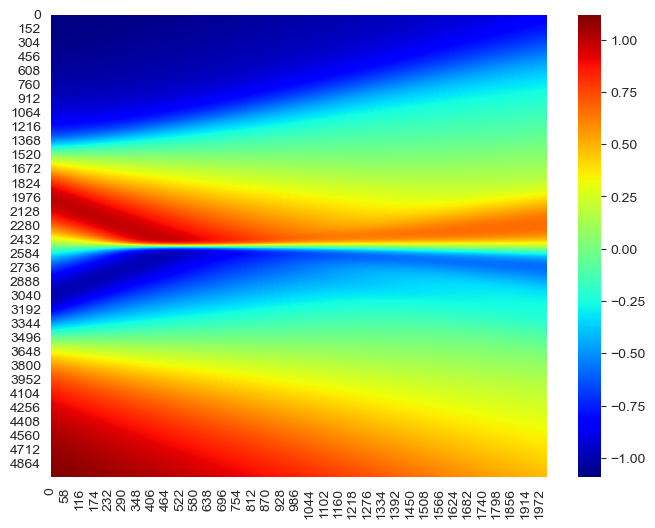

In [22]:
sns.set_style("white")
plt.figure(figsize=(8,6))
sns.heatmap(y_pred, cmap = 'jet')

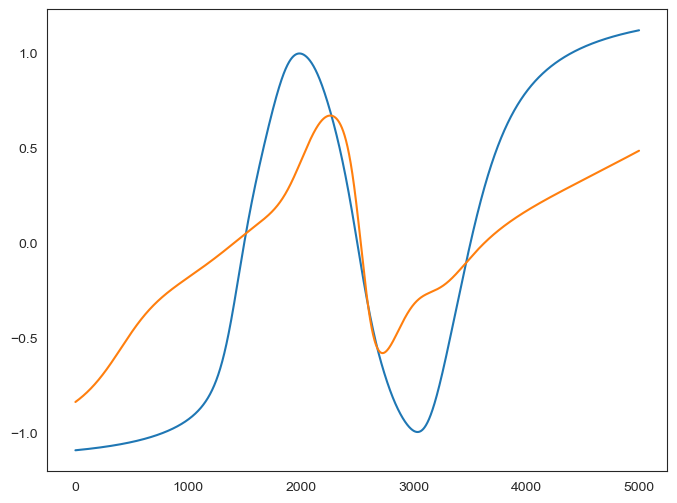

In [24]:
plt.figure(figsize=(8,6))
plt.plot(y_pred[:, 0])
plt.plot(y_pred[:, -1])
plt.show()